['Bream' 'Roach' 'Whitefish' 'Parkki' 'Perch' 'Pike' 'Smelt']
0.8907563025210085
0.85
['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']
[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]
['A' 'C']
['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']
[[0.99760007 0.00239993]
 [0.02737325 0.97262675]
 [0.99486386 0.00513614]
 [0.98585047 0.01414953]
 [0.99767419 0.00232581]]
['Bream' 'Smelt']
0.9327731092436975
0.925
['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']
[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]
(7, 5) (7,)
0.773109243697479
0.775
0.7983193277310925
0.775


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


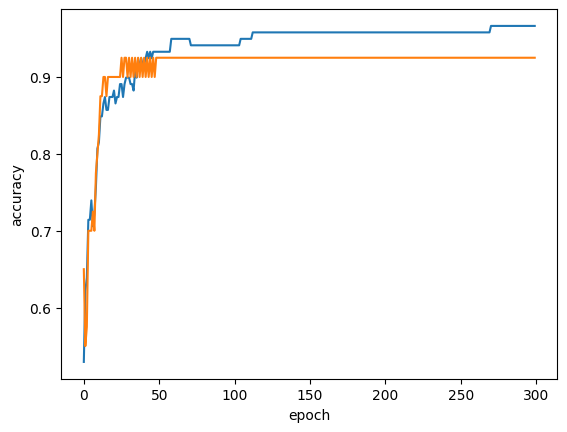

0.957983193277311
0.925


In [1]:
import pandas as pd

fish=pd.read_csv('http://bit.ly/fish_csv_data')
fish.head()

print(pd.unique(fish['Species']))
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_input.head()
fish_target=fish['Species']

from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

from sklearn.neighbors import KNeighborsClassifier
kn=KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled,train_target)
print(kn.score(train_scaled,train_target))
print(kn.score(test_scaled, test_target))

print(kn.classes_)
print(kn.predict(test_scaled[:5]))

import numpy as np
proba=kn.predict_proba(test_scaled[:5])
print(np.round(proba,decimals=4))

char_arr=np.array(['A','B','C','D','E'])
print(char_arr[[True,False,True,False,False]])

bream_smelt_indexes=(train_target=='Bream')|(train_target=='Smelt')
train_bream_smelt=train_scaled[bream_smelt_indexes]
target_bream_smelt=train_target[bream_smelt_indexes]

from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(train_bream_smelt,target_bream_smelt)
print(lr.predict(train_bream_smelt[:5]))

print(lr.predict_proba(train_bream_smelt[:5]))

print(lr.classes_)

lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

print(lr.predict(test_scaled[:5]))

proba=lr.predict_proba(test_scaled[:5])
print(np.round(proba,decimals=3))

print(lr.coef_.shape,lr.intercept_.shape)

import pandas as pd
fish=pd.read_csv('http://bit.ly/fish_csv_data')

fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_target=fish['Species']

from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

from sklearn.linear_model import SGDClassifier
sc=SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

sc.partial_fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

import numpy as np
sc=SGDClassifier(loss='log_loss', random_state=42)
train_score=[]
test_score=[]
classes=np.unique(train_target)

for _ in range(0,300):
    sc.partial_fit(train_scaled,train_target,classes=classes)
    train_score.append(sc.score(train_scaled,train_target))
    test_score.append(sc.score(test_scaled,test_target))

import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

sc=SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

In [3]:
import pandas as pd
fish=pd.read_csv('http://bit.ly/fish_csv_data')

fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_target=fish['Species']

from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)

import numpy as np
test_data = np.array([
    [350.0, 29.0, 33.5, 10.50, 4.60],
    [18.5, 12.5, 14.0, 2.30, 1.35],
    [820.0, 41.5, 45.0, 7.80, 5.10],
    [160.0, 21.0, 23.5, 6.20, 3.60],
    [550.0, 26.5, 31.0, 13.80, 6.10]
])

test_data_scaled = ss.transform(test_data)

print(lr.predict(test_data_scaled))
print(np.round(lr.predict_proba(test_data_scaled), decimals=3))

['Bream' 'Smelt' 'Pike' 'Perch' 'Whitefish']
[[0.451 0.049 0.008 0.006 0.384 0.    0.102]
 [0.    0.002 0.048 0.    0.009 0.941 0.   ]
 [0.    0.    0.287 0.713 0.    0.    0.   ]
 [0.    0.013 0.512 0.001 0.461 0.002 0.011]
 [0.368 0.094 0.    0.    0.009 0.    0.528]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


0.8067226890756303
0.875


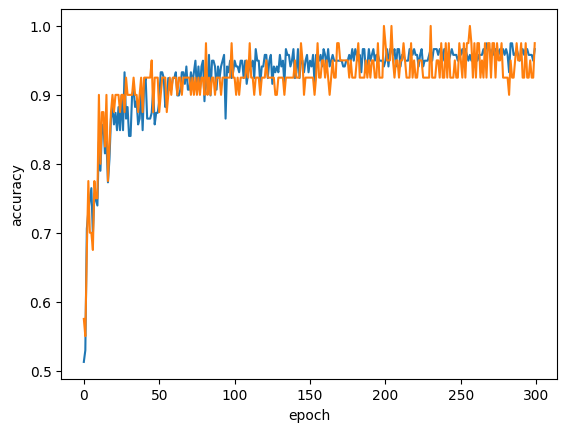

0.907563025210084
0.925


In [7]:
import pandas as pd
fish=pd.read_csv('http://bit.ly/fish_csv_data')

fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_target=fish['Species']

from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

from sklearn.linear_model import SGDClassifier
sc=SGDClassifier(loss='hinge', max_iter=10, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

import numpy as np
sc=SGDClassifier(loss='hinge', random_state=42)
train_score=[]
test_score=[]
classes=np.unique(train_target)

for _ in range(0,300):
    sc.partial_fit(train_scaled,train_target,classes=classes)
    train_score.append(sc.score(train_scaled,train_target))
    test_score.append(sc.score(test_scaled,test_target))

import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

#애매하긴 한데 100번 이후로 둘이 벌어지는 것 처럼 보임. 에포크 수 100으로 함

sc=SGDClassifier(loss='hinge', max_iter=100, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

#개선된 정확도를 보여주었음